## Phase 3: Supervised Classification

**Objective:** To identify NCAA Cinderella teams using a two step pipeline. First, we generated an unsupervised `Isolation_Score` to find statistical anomalies. Second we feed that score into supervised classifiers (Random Forest and XGBoost) to predict tournament over-performers.

### 0. Setup

In [1]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Keep all imports at the very top of the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, average_precision_score, recall_score
from xgboost import XGBClassifier
import shap

C:\Users\anton\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Data Loading and Feature Selection

Load the pre-processed metrics from the EDA phase and isolate the regular-season stats from the target variables. Create a `CinderellaFlag` variable in the data set.

In [3]:
# 1) Problem Context & Data Loading
print("Loading data and engineering advanced expectation gaps...")

df = pd.read_csv('../data/metrics.csv') 

# Drop rows missing critical features (keeps only tournament teams)
df = df.dropna(subset=['SeedNum', 'AvgScoreDiff', 'MasseyRankMean']).copy()

# ==========================================
# STEP 1: CALCULATE RAW ADVANCED METRICS FIRST
# ==========================================
df['FG_Pct'] = df['AvgFGM'] / df['AvgFGA']            
df['3P_Pct'] = df['AvgFGM3'] / df['AvgFGA3']          
df['FT_Pct'] = df['AvgFTM'] / df['AvgFTA']
df['Ast_TO_Ratio'] = df['AvgAssists'] / df['AvgTurnovers']
df['MasseyVariance'] = df['MasseyRankMean'] - df['MasseyRankMedian'] # High variance = polarizing team

# ==========================================
# STEP 2: CALCULATE TOURNAMENT AVERAGES
# ==========================================
# Group by Season to find the average regular-season stats for ALL tournament teams that year
tourney_avg_cols = ['AvgScoreDiff', 'MasseyRankMean', 'AvgPointsFor', 'FG_Pct', '3P_Pct', 'Ast_TO_Ratio', 'AvgSteals']

season_tourney_averages = df.groupby('Season')[tourney_avg_cols].mean().reset_index()

# Rename columns so we know they are averages
season_tourney_averages = season_tourney_averages.rename(columns={
    'AvgScoreDiff': 'TourneyAvg_ScoreDiff',
    'MasseyRankMean': 'TourneyAvg_Rank',
    'AvgPointsFor': 'TourneyAvg_PointsFor',
    'FG_Pct': 'TourneyAvg_FGPct',
    '3P_Pct': 'TourneyAvg_3PPct',
    'Ast_TO_Ratio': 'TourneyAvg_AstTO',
    'AvgSteals': 'TourneyAvg_Steals'
})

# Merge these averages back into the main dataframe
df = df.merge(season_tourney_averages, on='Season', how='left')

# ==========================================
# STEP 3: CALCULATE THE "EXPECTATION GAPS"
# ==========================================
# Positive number = better than the average tournament team
df['ScoreDiff_vs_TourneyAvg'] = df['AvgScoreDiff'] - df['TourneyAvg_ScoreDiff']
df['Rank_vs_TourneyAvg'] = df['TourneyAvg_Rank'] - df['MasseyRankMean'] # Flipped because lower rank is better
df['3PPct_vs_TourneyAvg'] = df['3P_Pct'] - df['TourneyAvg_3PPct']
df['FGPct_vs_TourneyAvg'] = df['FG_Pct'] - df['TourneyAvg_FGPct']
df['AstTO_vs_TourneyAvg'] = df['Ast_TO_Ratio'] - df['TourneyAvg_AstTO']
df['Steals_vs_TourneyAvg'] = df['AvgSteals'] - df['TourneyAvg_Steals']

# ==========================================
# STEP 4: FILTERING TO CINDERELLA CANDIDATES ONLY
# ==========================================
# We only want the model to evaluate low seeds (10-16). 
candidates_df = df[df['SeedNum'] >= 10].copy()

# Create Target: Did this specific underdog win 2+ games?
candidates_df['CinderellaFlag'] = (candidates_df['TourneyWins'] >= 2).astype(int)
candidates_df['CinderellaFlag'] = ((candidates_df['SeedNum'] >= 10) & (candidates_df['MaxTourneyDayNum'] >= 143)).astype(int)
# Define our massive new, highly contextual feature set
base_features = [
    'SeedNum', 'AvgScoreDiff',
    'WinPct', 
    'MasseyVariance',
    'ScoreDiff_vs_TourneyAvg', 
    'Rank_vs_TourneyAvg', 
    '3PPct_vs_TourneyAvg',     # Captures hot-shooting underdog threats
    'FGPct_vs_TourneyAvg',     # Captures overall offensive efficiency
    'AstTO_vs_TourneyAvg',     # Captures ball-security (crucial for upsets)
    'Steals_vs_TourneyAvg'     # Captures chaotic, disruptive defenses
]

# Drop any NAs generated by division math
candidates_df = candidates_df.replace([np.inf, -np.inf], np.nan).dropna(subset=base_features)

X = candidates_df[base_features].copy()
y = candidates_df['CinderellaFlag']

print(f"Candidate dataset created! Shape: {candidates_df.shape}")
print(f"Cinderellas found: {y.sum()} out of {len(y)} ({round(y.sum()/len(y)*100, 2)}%)")

Loading data and engineering advanced expectation gaps...
Candidate dataset created! Shape: (680, 53)
Cinderellas found: 45 out of 680 (6.62%)


### 2. Train/Test Split & CV Setup

Due to the extreme class imbalance (Cinderellas makes up <1% of the data), we use `StratifiedKFold` cross-validation to ensure the minority class is evently distributed across folds. Standard accuracy is discarded because of the class imbalance in favor of Precision-Recall AUC and F1-Score.

In [4]:
# Train/Test Split (Stratified to maintain the extreme 0.64% class imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Cross-Validation Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Custom scoring metrics (Accuracy is ignored due to class imbalance)
scoring = {
    'F1': make_scorer(f1_score), 
    'PR_AUC': make_scorer(average_precision_score), 
    'Recall': make_scorer(recall_score)
}

print(f"Training set shape: {X_train.shape}")
print(f"Cinderellas in training set: {sum(y_train)}")

Training set shape: (544, 10)
Cinderellas in training set: 36


### 3. Unsupervised Anomaly Detection

Before running our classifiers, we need to generate our novel feature. We use an Isolation Forest trained only on regular-season performance stats (ignoring seeds and rankings) to identify teams with highly unusual statistical profiles. High negative scores indicate a strong anomaly *(I know this is done for part 4, but it is what we said we would do)*.

In [5]:
print("Generating Unsupervised Anomaly Scores...")

# We use only regular season performance stats (no seeds or rankings) to find statistical anomalies
stats_for_anomaly = ['AvgScoreDiff',
    'WinPct', 
    'ScoreDiff_vs_TourneyAvg', 
    'Rank_vs_TourneyAvg', 
    '3PPct_vs_TourneyAvg',     # Captures hot-shooting underdog threats
    'FGPct_vs_TourneyAvg',     # Captures overall offensive efficiency
    'AstTO_vs_TourneyAvg',     # Captures ball-security (crucial for upsets)
    'Steals_vs_TourneyAvg' 
    ]

# Initialize Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# FIT ONLY ON TRAINING DATA to prevent leakage
iso_forest.fit(X_train[stats_for_anomaly])

# Transform both Train and Test sets
X_train = X_train.copy()
X_test = X_test.copy()

X_train['Isolation_Score'] = iso_forest.decision_function(X_train[stats_for_anomaly])
X_test['Isolation_Score'] = iso_forest.decision_function(X_test[stats_for_anomaly])

# Update our feature list to include this new unsupervised feature for Phase 2
features = base_features + ['Isolation_Score']

print("Phase 1 Complete: 'Isolation_Score' successfully added to the feature set.")

Generating Unsupervised Anomaly Scores...
Phase 1 Complete: 'Isolation_Score' successfully added to the feature set.


### 4. Baseline Model: Random Forest

We begin with a Random Forest classifier to establish a baseline for how tree-based model handle the engineered anomaly scores alongside traditional seeding.

In [6]:
print("Training Random Forest Baseline...\n")

# Build the pipeline
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Define hyperparameters to search
rf_param_grid = {
    'rf__n_estimators': [100],
    'rf__max_depth': [5, 10]
}

# Run Grid Search
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=cv, scoring=scoring, refit='PR_AUC')
rf_grid.fit(X_train, y_train)

# Output results
print("Best RF Params:", rf_grid.best_params_)
print("RF Cross-Val PR-AUC:", round(rf_grid.cv_results_['mean_test_PR_AUC'][rf_grid.best_index_], 4))
print("RF Cross-Val F1:", round(rf_grid.cv_results_['mean_test_F1'][rf_grid.best_index_], 4))
print("RF Cross-Val Recall:", round(rf_grid.cv_results_['mean_test_Recall'][rf_grid.best_index_], 4))

Training Random Forest Baseline...

Best RF Params: {'rf__max_depth': 5, 'rf__n_estimators': 100}
RF Cross-Val PR-AUC: 0.1177
RF Cross-Val F1: 0.2064
RF Cross-Val Recall: 0.2429


### 5. Advanced Model: XGBoost

XGBoost provides finer control over the extreme class imbalance via the `scale_pos_weight` parameter. We tune this alongside  learning rate and tree depth to maximize precision and recall.

In [7]:
print("Training Small-Data Regularized XGBoost Model...\n")

# Build the pipeline (REMOVING SMOTE - it often adds noisy data to small datasets)
xgb_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Recalculate the weight for the NEW 10-to-1 ratio
weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# The "Small Data" Hyperparameter Grid
xgb_param_grid = {
    # 1. Keep trees incredibly shallow to prevent memorizing the small dataset
    'xgb__max_depth': [2, 3], 
    
    # 2. Slow down learning
    'xgb__learning_rate': [0.01, 0.05],
    
    # 3. Hover exactly around the new true ratio (~10)
    'xgb__scale_pos_weight': [weight * 0.8, weight, weight * 1.2], 
    
    # 4. CRITICAL REGULARIZATION: Force it to drop features
    'xgb__colsample_bytree': [0.5, 0.7], 
    
    # 5. NEW REGULARIZATION: Gamma prunes useless branches
    'xgb__gamma': [0.1, 0.5, 1.0],
    
    # 6. NEW REGULARIZATION: Min Child Weight stops it from making rules for 1 or 2 outlier teams
    'xgb__min_child_weight': [3, 5]
}

# Run Grid Search
xgb_grid = GridSearchCV(xgb_pipe, xgb_param_grid, cv=cv, scoring=scoring, refit='PR_AUC')
xgb_grid.fit(X_train, y_train)

# Output results
print("Best XGB Params:", xgb_grid.best_params_)
print("XGB Cross-Val PR-AUC:", round(xgb_grid.cv_results_['mean_test_PR_AUC'][xgb_grid.best_index_], 4))
print("XGB Cross-Val F1:", round(xgb_grid.cv_results_['mean_test_F1'][xgb_grid.best_index_], 4))
print("XGB Cross-Val Recall:", round(xgb_grid.cv_results_['mean_test_Recall'][xgb_grid.best_index_], 4))

Training Small-Data Regularized XGBoost Model...

Best XGB Params: {'xgb__colsample_bytree': 0.5, 'xgb__gamma': 0.1, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 2, 'xgb__min_child_weight': 5, 'xgb__scale_pos_weight': 11.28888888888889}
XGB Cross-Val PR-AUC: 0.1571
XGB Cross-Val F1: 0.2961
XGB Cross-Val Recall: 0.6679


### 6. Model Explainability (SHAP)

To understand how the XGBoost model is making its predictions, we utilize SHapley Additive exPlanations (SHAP). This summary plot shows the directional impact of each feature on the model's output.

Generating SHAP summary plot...


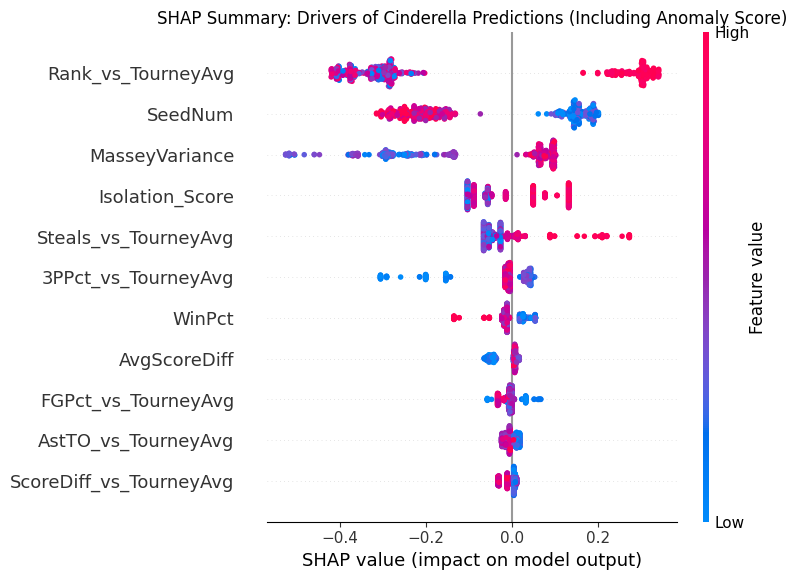

In [8]:
print("Generating SHAP summary plot...")

# Extract the trained model and scaler from the best XGBoost pipeline
best_xgb = xgb_grid.best_estimator_.named_steps['xgb']
scaler = xgb_grid.best_estimator_.named_steps['scaler']

# Scale the training data so SHAP can interpret it correctly
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=features)

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_train_scaled)

# Plot the summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_scaled, show=False)

# Formatting and saving
plt.title("SHAP Summary: Drivers of Cinderella Predictions (Including Anomaly Score)")
plt.tight_layout()

# Make sure the 'assets' folder exists in your directory tree
import os
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/shap_summary.png', dpi=300, bbox_inches='tight')

plt.show()

### 7. Export Models and Data

In [9]:
import joblib
import os

print("Exporting trained models for deployment...")

# 1. Save the best XGBoost Model
# We extract the specific XGBoost step from the pipeline
best_xgb_model = xgb_grid.best_estimator_.named_steps['xgb']
joblib.dump(best_xgb_model, '../models/xgboost_model.pkl')

# 2. Save the Isolation Forest Model (from Phase 1)
joblib.dump(iso_forest, '../models/isolation_forest.pkl')

# 3. Save the Scaler (so the Streamlit app scales user inputs correctly)
scaler = xgb_grid.best_estimator_.named_steps['scaler']
joblib.dump(scaler, '../models/scaler.pkl')

print("Success! Models saved to the /models folder.")

Exporting trained models for deployment...
Success! Models saved to the /models folder.


Calculating XGBoost Feature Importances...

--- Top 10 Most Important Features ---
                   Feature  Importance
0       Rank_vs_TourneyAvg    0.270842
1                  SeedNum    0.201865
2           MasseyVariance    0.114666
3      3PPct_vs_TourneyAvg    0.071719
4     Steals_vs_TourneyAvg    0.068598
5             AvgScoreDiff    0.061516
6          Isolation_Score    0.054275
7      FGPct_vs_TourneyAvg    0.048093
8                   WinPct    0.042306
9  ScoreDiff_vs_TourneyAvg    0.033099


C:\Users\anton\AppData\Local\Temp\ipykernel_58680\279892942.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


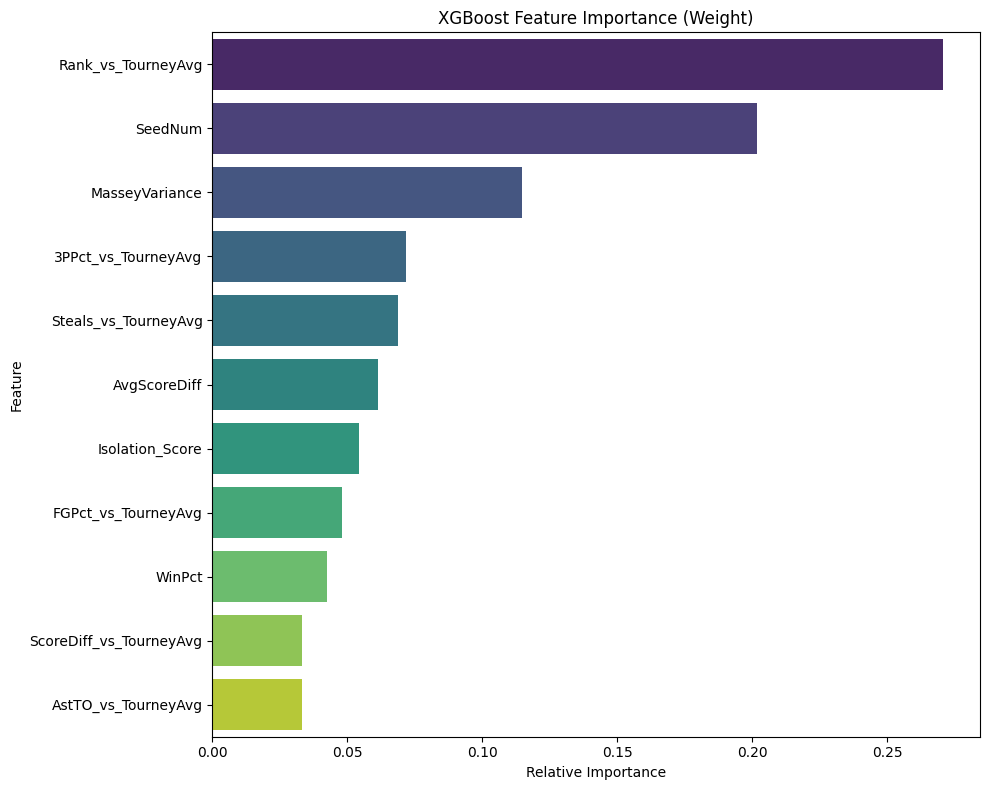

In [10]:
import seaborn as sns

print("Calculating XGBoost Feature Importances...")

# Extract the importance weights from the best XGBoost model
importances = best_xgb.feature_importances_

# Create a DataFrame matching features to their importance score
importance_df = pd.DataFrame({
    'Feature': features, # 'features' includes base_features + 'Isolation_Score'
    'Importance': importances
})

# Sort them from most important to least
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Print the top 10
print("\n--- Top 10 Most Important Features ---")
print(importance_df.head(10))

# Plot them
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('XGBoost Feature Importance (Weight)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Tuning Prediction Threshold...
Default 0.50 Threshold F1: 0.3373
Optimal Threshold: 0.5009
New Tuned F1 Score: 0.2909


C:\Users\anton\AppData\Local\Temp\ipykernel_58680\637151896.py:13: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls)


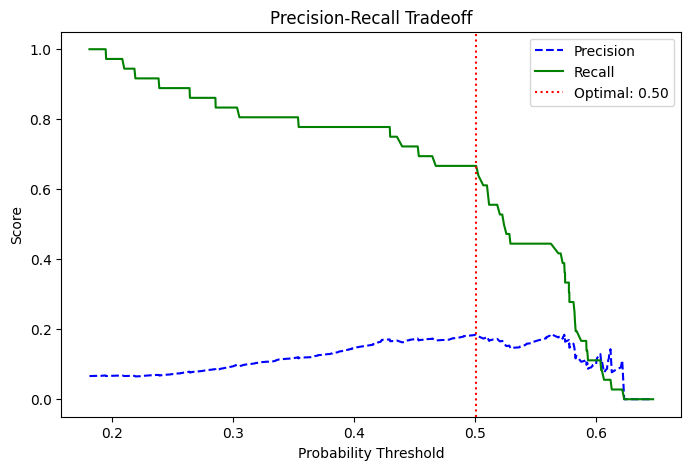

In [11]:
from sklearn.metrics import precision_recall_curve

print("Tuning Prediction Threshold...")

# Get the raw probabilities for the training set using cross-validation
from sklearn.model_selection import cross_val_predict
y_scores = cross_val_predict(xgb_grid.best_estimator_, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

# Calculate F1 scores for every threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores) # Handle division by zero

# Find the threshold that gives the highest F1 Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Default 0.50 Threshold F1: {f1_score(y_train, xgb_grid.predict(X_train)):.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"New Tuned F1 Score: {f1_scores[optimal_idx]:.4f}")

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.axvline(x=optimal_threshold, color='r', linestyle=':', label=f'Optimal: {optimal_threshold:.2f}')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff')
plt.legend()
plt.show()